In [1]:
import numpy as np
import time
import pybullet as p
import pybullet_data
import scipy
import math
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from get_robot_iiwa import sim_robot
import pickle
from matplotlib.patches import Ellipse
import mpl_toolkits.mplot3d.art3d as art3d
from gmr import GMM, plot_error_ellipses, plot_error_ellipses_diff_position, plot_error_ellipses_3d_position 

pybullet build time: Oct 14 2023 15:43:53


In [2]:
path_folder = 'data/iiwa_dataset_mice'

joint_pos = np.load(path_folder+'/q_list.npy')

with open(path_folder + '/Joint_X_pos.pkl', 'rb') as f:
    Joint_X_pos = pickle.load(f)

with open(path_folder + '/Jacobians.pkl', 'rb') as f:
    Jacobians = pickle.load(f)

with open(path_folder + '/l.pkl', 'rb') as f:
    l = pickle.load(f)

with open(path_folder + '/v_max.pkl', 'rb') as f:
    v_max = pickle.load(f)

N = joint_pos.shape[0]
print(N)

2157817


In [3]:
X_4 = Joint_X_pos['4']
X_5 = Joint_X_pos['5']
X_6 = Joint_X_pos['6']

X_5_split = np.hsplit(X_5[::200], 3)
X_6_split = np.hsplit(X_6[::200], 3)

l_4 = l['4']
l_5 = l['5']
l_6 = l['6']


v_4 = v_max['4']
v_5 = v_max['5']
v_6 = v_max['6']
print(np.array(X_6).shape)

(2157817, 3)


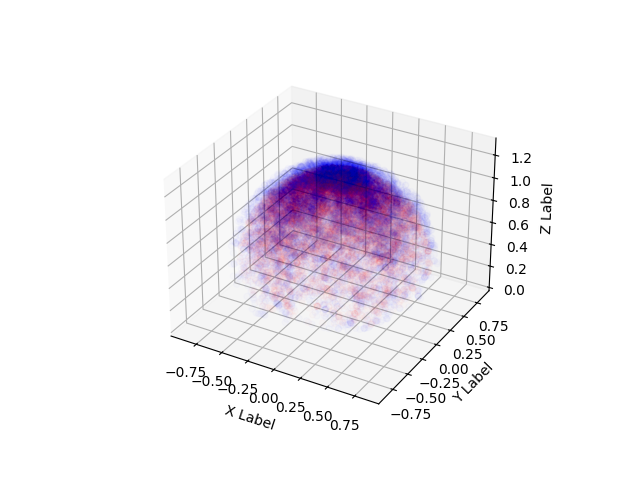

In [4]:
# %matplotlib notebook
%matplotlib widget
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(X_6_split[0], X_6_split[1], X_6_split[2], color='b', alpha = 0.01)
ax.scatter(X_5_split[0], X_5_split[1], X_5_split[2], color='r', alpha = 0.01)

ax.set_xlabel('X Label')
ax.set_ylabel('Y Label')
ax.set_zlabel('Z Label')

ax.tick_params(axis='both', which='major', labelsize=10)

plt.show()

## Plot a simple heat map

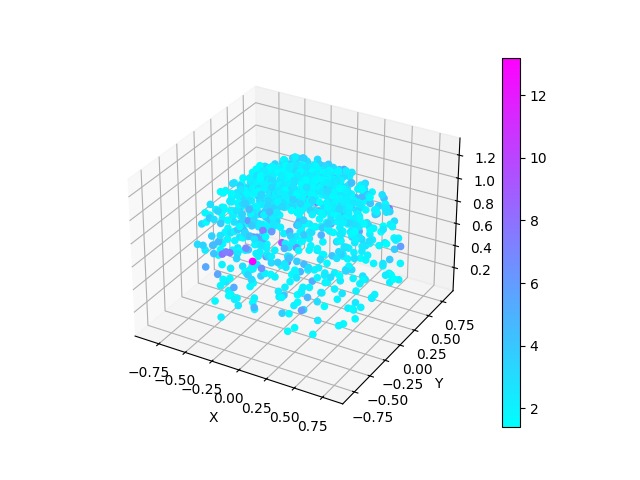

In [5]:
l6 = l_6[::2000]
X6 = X_6[::2000]
v6 = v_6[::2000]

idx = l6 <= 15

l_6_data = l6[idx]
X_6_data = X6[idx, :]

n_data = X_6_data.shape[0]

v_dir = np.array([0, 1, 0])
v_dir_tile = np.tile(v_dir, (n_data, 1))
v_dir_tile = v_dir_tile.astype(float)

v_dir_tile = np.multiply(v_dir_tile, l_6_data[:, np.newaxis])

%matplotlib widget

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
img = ax.scatter(X_6_data[:,0], X_6_data[:,1], X_6_data[:,2], c = l_6_data, cmap = 'cool', alpha = 1)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

fig.colorbar(img)

plt.show()

# GMM GMR

In [6]:
## Joint 6 (starting from the number 0)
l6 = l_6[::1000]
X6 = X_6[::1000]
v6 = v_6[::1000]

idx = l6 <= 10

l_6_data = l6[idx]
X_6_data = X6[idx, :]
v_6_data = v6[idx]

print(X_6_data.shape)
print(l_6_data.shape)
print(v_6_data.shape)

n_6_data = X_6_data.shape[0]


## Joint 5 (starting from the number 0)
l5 = l_5[::1000]
X5 = X_5[::1000]
v5 = v_5[::1000]

idx = l5 <= 20

l_5_data = l5[idx]
X_5_data = X5[idx, :]
v_5_data = v5[idx]

print(X_5_data.shape)
print(l_5_data.shape)
print(v_5_data.shape)

n_5_data = X_5_data.shape[0]

##########

l4 = l_4[::1000]
X4 = X_4[::1000]
v4 = v_4[::1000]

idx = l4 <= 20

l_4_data = l4[idx]
X_4_data = X4[idx, :]
v_4_data = v4[idx]



(2151, 3)
(2151,)
(2151,)
(2150, 3)
(2150,)
(2150,)


In [7]:
input_6 = np.concatenate((X_6_data, l_6_data.reshape(-1, 1), v_6_data.reshape(-1, 1)), axis=1)
input_5 = np.concatenate((X_5_data, l_5_data.reshape(-1, 1), v_5_data.reshape(-1, 1)), axis=1)

input_lv = np.concatenate(( l_6_data.reshape(-1, 1), v_6_data.reshape(-1, 1)), axis=1)

gmm_lv = GMM(n_components=3, random_state = 0)
gmm_lv.from_samples(input_lv, init_params="kmeans++")

gmm_full_6 = GMM(n_components=1, random_state = 0)
gmm_full_6.from_samples(input_6, init_params="kmeans++")

gmm_full_5 = GMM(n_components=1, random_state = 0)
gmm_full_5.from_samples(input_5, init_params="kmeans++")

# given_position_test = np.array([0.5, 0.3, 0.3])
# gmm_lv_cond_test = gmm_full.condition(np.array([0,1,2]), given_position_test)


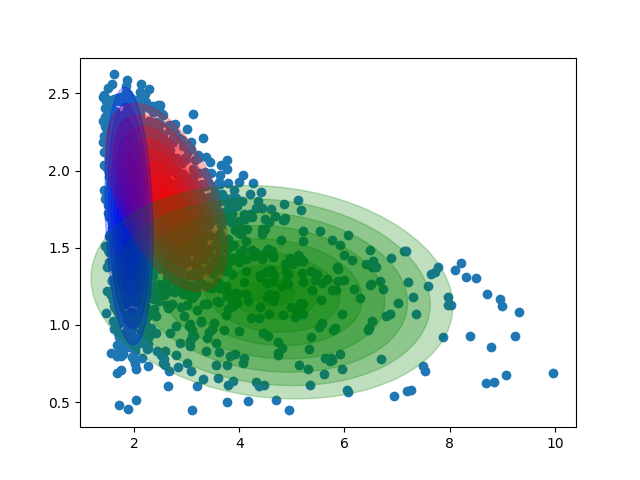

In [8]:
%matplotlib widget

plt.figure()
plt.scatter(l_6_data, v_6_data)
# plt.scatter(l_5_data, v_5_data)
# plt.scatter(l_4_data, v_4_data)
plot_error_ellipses(plt.gca(), gmm_lv, colors = ['r', 'g', 'b'])
plt.show()

[[2.69522644 1.62658228]]


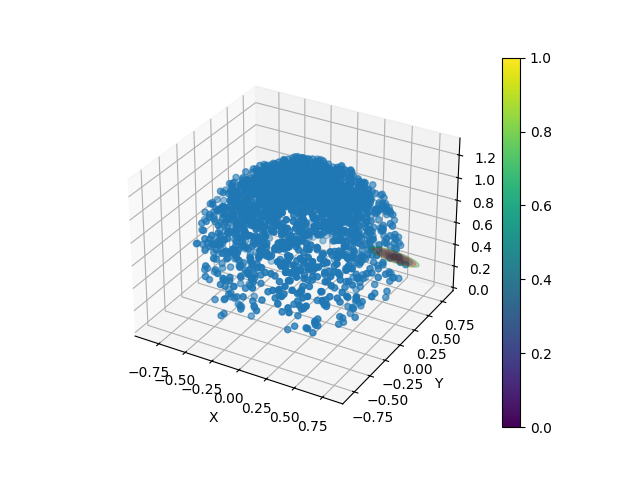

In [9]:
%matplotlib widget

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# img = ax.scatter(X_6_data[:,0], X_6_data[:,1], X_6_data[:,2], c = l_6_data, cmap = 'cool', alpha = 1)
img = ax.scatter(X_6_data[:,0], X_6_data[:,1], X_6_data[:,2])

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

fig.colorbar(img)

# Plotting a few different GMMs
for i in range(1):
    given_position = X_6_data[i*50,:]
    # print(given_position)
    gmm_lv_x_6 = gmm_full_6.condition(np.array([0,1,2]), given_position)
    print(gmm_lv_x_6.means)
    plot_error_ellipses_3d_position(plt.gca(), gmm_lv_x_6, given_position, colors = ['r', 'g', 'b'])
plt.show()

[0.69149345 0.17403001 0.61898297]   [[5.41178663 1.36373206]]
[0.69149345 0.17403001 0.61898297]   [[2.67940189 1.63145047]]
[0.44315204 0.13730837 1.03597009]   [[4.73774006 1.44024021]]
[0.44315204 0.13730837 1.03597009]   [[2.53156053 1.72758347]]
[-0.48898196 -0.43801203  0.64390755]   [[5.62184822 1.35595876]]
[-0.48898196 -0.43801203  0.64390755]   [[2.68527204 1.60140374]]
[ 0.15598327 -0.48923573  0.85012633]   [[5.26978728 1.3880909 ]]
[ 0.15598327 -0.48923573  0.85012633]   [[2.55809252 1.65409852]]
[ 0.01644679 -0.07745633  1.13247621]   [[4.66544421 1.45361955]]
[ 0.01644679 -0.07745633  1.13247621]   [[2.50066728 1.73793964]]
[ 0.44628489 -0.51314777  0.28477085]   [[6.21025104 1.2822959 ]]
[ 0.44628489 -0.51314777  0.28477085]   [[2.75407805 1.52024119]]
[0.01777812 0.16228265 1.14816248]   [[4.55859658 1.46410702]]
[0.01777812 0.16228265 1.14816248]   [[2.51901347 1.75186486]]
[-0.34222123 -0.46521246  0.43182006]   [[5.97931274 1.31546122]]
[-0.34222123 -0.46521246  0.

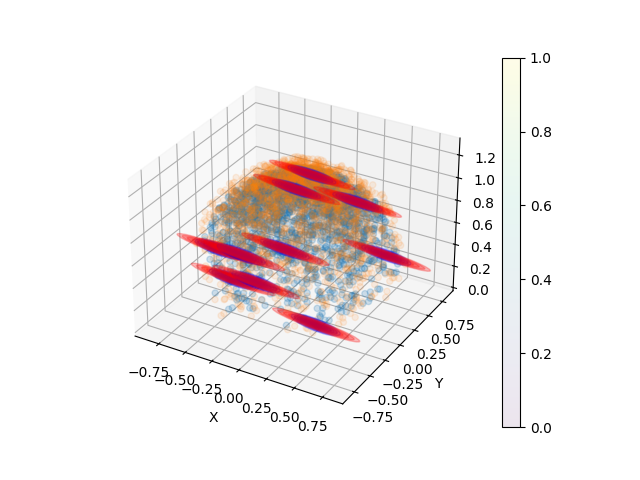

In [12]:
%matplotlib widget

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# img = ax.scatter(X_6_data[:,0], X_6_data[:,1], X_6_data[:,2], c = l_6_data, cmap = 'cool', alpha = 1)
img = ax.scatter(X_5_data[:,0], X_5_data[:,1], X_5_data[:,2],  alpha = 0.2)
img = ax.scatter(X_6_data[:,0], X_6_data[:,1], X_6_data[:,2], alpha = 0.1)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

fig.colorbar(img)

# Plotting a few different GMMs
for i in range(10):
    given_position = X_5_data[i*50,:]
    # print(given_position)
    gmm_lv_x_5 = gmm_full_5.condition(np.array([0,1,2]), given_position)
    gmm_lv_x_6 = gmm_full_6.condition(np.array([0,1,2]), given_position)
    
    print(given_position, " ", gmm_lv_x_5.means)
    print(given_position, " ", gmm_lv_x_6.means)
    plot_error_ellipses_3d_position(plt.gca(), gmm_lv_x_5, given_position, colors = ['r'])
    plot_error_ellipses_3d_position(plt.gca(), gmm_lv_x_6, given_position, colors = ['b'])
plt.show()